In [2]:
import warnings 
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
# Core Libraries required for Visualization and Data Handling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Machine Learning Evaluation Metrics used for Analyzing Results

from sklearn.model_selection import train_test_split
from sklearn.metrics import (recall_score, confusion_matrix, classification_report)


In [4]:
# Loading Credit Card Transaction Dataset 

df = pd.read_csv("creditcard_data.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Class Distribution of Fraud and Legitimate Transactions

class_counts = df["Class"].value_counts()

print("\nClass Distribution:")
print(class_counts)
print("\nFraud percentage:")
print((class_counts[1] / class_counts.sum()) *100)


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage:
0.1727485630620034


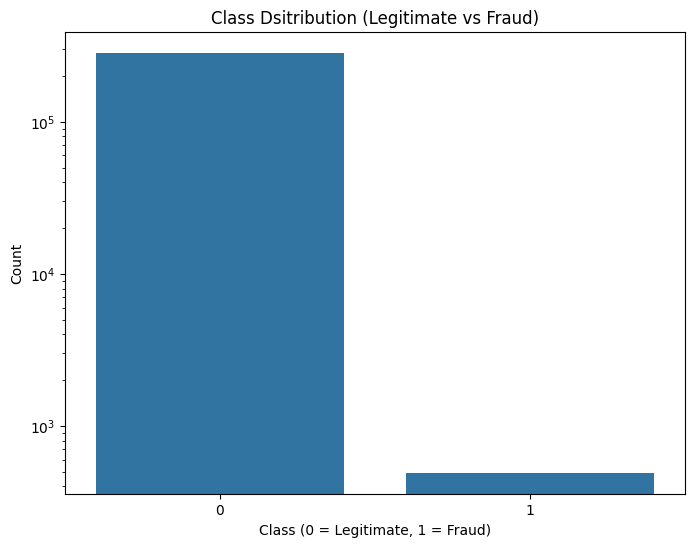

In [6]:
# Intial Plot of Fraud Transaction vs Legitimate Transaction

plt.figure(figsize=(8,6))
sns.countplot(x= "Class", data = df)
plt.yscale("log")
plt.title("Class Dsitribution (Legitimate vs Fraud)")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [7]:
# Train-Test Split Startifiaction

RANDOM_STATE =42
X = df.drop("Class", axis=1)
Y = df["Class"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.30,
    random_state=RANDOM_STATE,
    stratify= Y
)

print("Train Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)

print("\nClass distribution in trainig Set:")
print(Y_train.value_counts())

print("\nClass distribution in test Set:")
print(Y_test.value_counts())

Train Set Shape: (199364, 30)
Test Set Shape: (85443, 30)

Class distribution in trainig Set:
Class
0    199020
1       344
Name: count, dtype: int64

Class distribution in test Set:
Class
0    85295
1      148
Name: count, dtype: int64


In [8]:
# Model 1 : Logistic Regression

from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000)
LR_model.fit(X_train, Y_train)
Y_pred_LR = LR_model.predict(X_test)
LR_TPR = recall_score(Y_test, Y_pred_LR)

print("Logistic Regression Baseline TPR (Recall):", LR_TPR)
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_LR))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_LR))

Logistic Regression Baseline TPR (Recall): 0.6554054054054054

Confusion Matrix:
 [[85277    18]
 [   51    97]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.74       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



In [9]:
# Model 2 : Random Forest


from sklearn.ensemble import RandomForestClassifier

RF_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
RF_model.fit(X_train, Y_train)
Y_pred_RF = RF_model.predict(X_test)
RF_TPR = recall_score(Y_test, Y_pred_RF)

print("Random Forest Classiifier TPR (Recall):", RF_TPR)
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_RF))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_RF))

Random Forest Classiifier TPR (Recall): 0.7567567567567568

Confusion Matrix:
 [[85290     5]
 [   36   112]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443



In [10]:
# Model 2 : Gradient Boosting


from sklearn.ensemble import GradientBoostingClassifier

GB_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
GB_model.fit(X_train, Y_train)
Y_pred_GB = GB_model.predict(X_test)
GB_TPR = recall_score(Y_test, Y_pred_GB)

print("Gradient Boosting Classifier TPR (Recall):", GB_TPR)
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_GB))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_GB))

Gradient Boosting Classifier TPR (Recall): 0.16216216216216217

Confusion Matrix:
 [[85286     9]
 [  124    24]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.73      0.16      0.27       148

    accuracy                           1.00     85443
   macro avg       0.86      0.58      0.63     85443
weighted avg       1.00      1.00      1.00     85443



In [11]:
# Model 2 : XGBoost


from xgboost import XGBClassifier

XGB_model = XGBClassifier(
    n_estimators =100,
    learning_rate =0.1,
    max_depth =6,
    random_stae=RANDOM_STATE,
    eval_metric="logloss"
)


XGB_model.fit(X_train, Y_train)
Y_pred_XGB = XGB_model.predict(X_test)
XGB_TPR = recall_score(Y_test, Y_pred_XGB)

print("XGBoost Baseline TPR (Recall):", XGB_TPR)
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_XGB))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_XGB))

D:\DEV\PythonLibs\xgboost\training.py:199: UserWarning: [14:19:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "random_stae" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Baseline TPR (Recall): 0.7364864864864865

Confusion Matrix:
 [[85289     6]
 [   39   109]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.95      0.74      0.83       148

    accuracy                           1.00     85443
   macro avg       0.97      0.87      0.91     85443
weighted avg       1.00      1.00      1.00     85443



In [12]:
# Imbalance Handling Using SMOTE

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

# Class Distribution After SMOTE

print("Class Distribution after SMOTE:")
print(Y_train_smote.value_counts())

Class Distribution after SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64


In [13]:
# Logistic Regression + SMOTE 

LR_model_smote = LogisticRegression(max_iter=3000, n_jobs=-1)
LR_model_smote.fit(X_train_smote, Y_train_smote)

LR_Pred_smote = LR_model_smote.predict(X_test)

print("LogisticRegression + SMOTE TPR:", recall_score(Y_test, LR_Pred_smote))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, LR_Pred_smote))
print("\nClassification Report:\n", classification_report(Y_test, LR_Pred_smote))


D:\DEV\PythonLibs\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogisticRegression + SMOTE TPR: 0.8513513513513513

Confusion Matrix:
 [[84562   733]
 [   22   126]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     85295
           1       0.15      0.85      0.25       148

    accuracy                           0.99     85443
   macro avg       0.57      0.92      0.62     85443
weighted avg       1.00      0.99      0.99     85443



In [14]:
# Random Forest + SMOTE

RF_model_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


RF_model_smote.fit(X_train_smote, Y_train_smote)

RF_Pred_smote = RF_model_smote.predict(X_test)

print("Random Forest + SMOTE TPR:", recall_score(Y_test, RF_Pred_smote))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, RF_Pred_smote))
print("\nClassification Report:\n", classification_report(Y_test, RF_Pred_smote))

Random Forest + SMOTE TPR: 0.7972972972972973

Confusion Matrix:
 [[85278    17]
 [   30   118]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.80      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



In [15]:
# Gradient Boosting + SMOTE

GB_model_smote = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)


GB_model_smote.fit(X_train_smote, Y_train_smote)

GB_Pred_smote = GB_model_smote.predict(X_test)

print("Gradient Boosting + SMOTE TPR:", recall_score(Y_test, GB_Pred_smote))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, GB_Pred_smote))
print("\nClassification Report:\n", classification_report(Y_test, GB_Pred_smote))

Gradient Boosting + SMOTE TPR: 0.8108108108108109

Confusion Matrix:
 [[85151   144]
 [   28   120]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.45      0.81      0.58       148

    accuracy                           1.00     85443
   macro avg       0.73      0.90      0.79     85443
weighted avg       1.00      1.00      1.00     85443



In [16]:
# XGBoost + SMOTE

XGB_model_smote = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)


XGB_model_smote.fit(X_train_smote, Y_train_smote)

XGB_Pred_smote = XGB_model_smote.predict(X_test)

print("XGBoost + SMOTE TPR:", recall_score(Y_test, XGB_Pred_smote))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, XGB_Pred_smote))
print("\nClassification Report:\n", classification_report(Y_test, XGB_Pred_smote))

XGBoost + SMOTE TPR: 0.8445945945945946

Confusion Matrix:
 [[85144   151]
 [   23   125]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.45      0.84      0.59       148

    accuracy                           1.00     85443
   macro avg       0.73      0.92      0.79     85443
weighted avg       1.00      1.00      1.00     85443



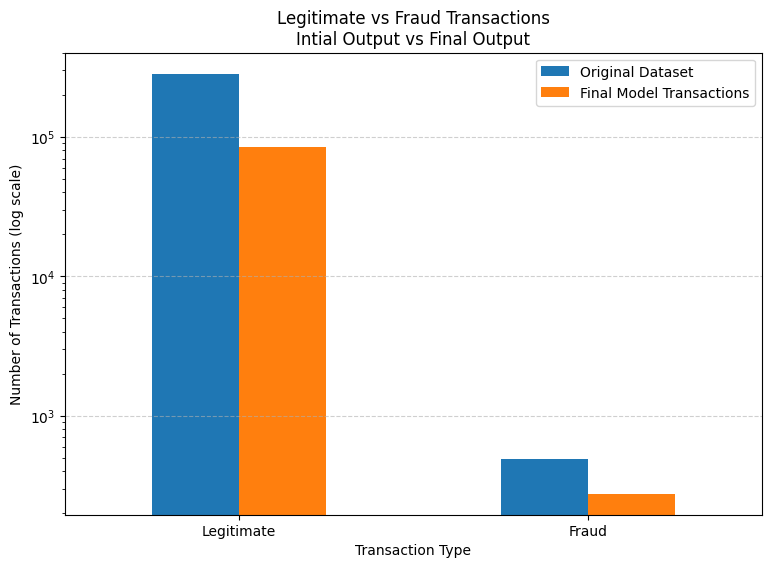

In [17]:
# Final Plot of Fraud vs Legitimate transaction after XGBoost + SMOTE 


# Intial Class Distribution

Intial_counts = df['Class'].value_counts().sort_index() 

# Final Class Distribution after XGBoost + SMOTE

Final_pred_counts = pd.Series(XGB_Pred_smote).value_counts().sort_index() 


Comparison_df = pd.DataFrame({
    "Original Dataset": Intial_counts,
    "Final Model Transactions": Final_pred_counts

})


Comparison_df.plot(
    kind = "bar",
    figsize = (9,6),
    logy=True
)

plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)
plt.ylabel("Number of Transactions (log scale)")
plt.xlabel("Transaction Type")
plt.title("Legitimate vs Fraud Transactions\nIntial Output vs Final Output")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()